### Brief data exploration

In [1]:
from utils.download_data import download_and_extract
download_and_extract()

Dataset already present: ['e-shop clothing 2008.csv']
Delete the CSV files in data/ and re-run if you want to re-download.


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
spark = SparkSession.builder.appName("Data_exploration").master("local[*]").getOrCreate()
spark.conf.set("spark.sql.ansi.enabled", False)
print(spark.sparkContext.defaultParallelism)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/05 14:32:32 WARN Utils: Your hostname, DESKTOP-UQF5BSK, resolves to a loopback address: 127.0.1.1; using 172.24.225.163 instead (on interface eth0)
26/04/05 14:32:32 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/05 14:32:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/05 14:32:35 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


8


In [3]:
df = spark.read.csv("../data/e-shop clothing 2008.csv", inferSchema=True, header=True, sep=";")

## Inferred schema

In [4]:
df.printSchema()
df.show(5)

root
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- order: integer (nullable = true)
 |-- country: integer (nullable = true)
 |-- session ID: integer (nullable = true)
 |-- page 1 (main category): integer (nullable = true)
 |-- page 2 (clothing model): string (nullable = true)
 |-- colour: integer (nullable = true)
 |-- location: integer (nullable = true)
 |-- model photography: integer (nullable = true)
 |-- price: integer (nullable = true)
 |-- price 2: integer (nullable = true)
 |-- page: integer (nullable = true)

+----+-----+---+-----+-------+----------+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+
|year|month|day|order|country|session ID|page 1 (main category)|page 2 (clothing model)|colour|location|model photography|price|price 2|page|
+----+-----+---+-----+-------+----------+----------------------+-----------------------+------+--------+-----------------+-

### Basic stats for the only continous variable in the dataset

In [5]:
stats = df.select("price").describe()
stats.show()

+-------+------------------+
|summary|             price|
+-------+------------------+
|  count|            165474|
|   mean|43.802506738218696|
| stddev|12.548131195655683|
|    min|                18|
|    max|                82|
+-------+------------------+



### NAs and uniques

In [6]:
distinct = df.select([F.count_distinct(c).alias(c) for c in df.columns])
null = df.select([F.sum(F.isnull(c).cast("int")).alias(c + " NA") for c in df.columns]).transpose()
print("Unique counts")
distinct.show()
print("NA counts")
null.show()

Unique counts


+----+-----+---+-----+-------+----------+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+
|year|month|day|order|country|session ID|page 1 (main category)|page 2 (clothing model)|colour|location|model photography|price|price 2|page|
+----+-----+---+-----+-------+----------+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+
|   1|    5| 31|  195|     47|     24026|                     4|                    217|    14|       6|                2|   20|      2|   5|
+----+-----+---+-----+-------+----------+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+

NA counts
+--------------------+---+
|                 key|  0|
+--------------------+---+
|            month NA|  0|
|              day NA|  0|
|            order NA|  0|
|          country NA|  0|
|       session ID NA|  0|
|page 1 (main cate...|  0|
|page 2 (clothing ...|  0|
|        

### Session lengths stats

In [7]:
durations = df.groupBy(df["session ID"]).count().select("count").describe()
durations.show()

+-------+------------------+
|summary|             count|
+-------+------------------+
|  count|             24026|
|   mean|6.8872887704986265|
| stddev|  8.99516063206717|
|    min|                 1|
|    max|               195|
+-------+------------------+



### Most amount of clicks ending in specific category or product

In [8]:
df = df.withColumnsRenamed({"page 1 (main category)": "main_category", "page 2 (clothing model)": "clothing_model", "Session ID" : "ID"})

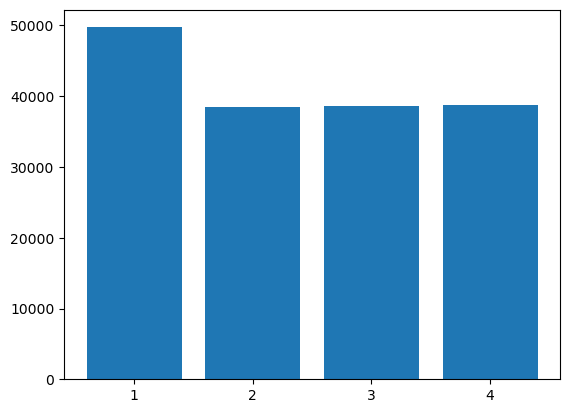

+--------------+-----+
|clothing_model|count|
+--------------+-----+
|            B4| 3579|
|            A2| 3013|
|           A11| 2789|
|            P1| 2681|
|           B10| 2566|
|            A4| 2522|
|           A15| 2489|
|            A5| 2354|
|           A10| 2280|
|            A1| 2265|
|           A12| 2010|
|            A3| 1932|
|            A9| 1923|
|           B13| 1919|
|           B24| 1879|
|            C5| 1834|
|            A6| 1802|
|            A7| 1622|
|            A8| 1585|
|           A13| 1577|
+--------------+-----+
only showing top 20 rows


In [9]:
import matplotlib.pyplot as plt
bars = df.groupBy(df.main_category).count().toPandas()
plt.bar(bars["main_category"], height= bars["count"])
plt.xticks(bars["main_category"])
plt.show()
df.groupBy(df.clothing_model).count().sort("count", ascending = False).show()

### Data card

Authors of dataset provided following information on features present: Data is already encoded. No missing values. 

Variables:

1. YEAR (2008)

2. MONTH -> from April (4) to August (8)

3. DAY -> day number of the month

4. ORDER -> sequence of clicks during one session

5. COUNTRY -> variable indicating the country of origin of the IP address with the 
following categories: (1-Australia, 2-Austria, 3-Belgium 4-British, Virgin Islands, 5-Cayman Islands, 6-Christmas Island, 7-Croatia, 8-Cyprus, 9-Czech Republic,
10-Denmark,
11-Estonia,
12-unidentified,
13-Faroe Islands,
14-Finland,
15-France,
16-Germany,
17-Greece,
18-Hungary,
19-Iceland,
20-India,
21-Ireland,
22-Italy,
23-Latvia,
24-Lithuania,
25-Luxembourg,
26-Mexico,
27-Netherlands,
28-Norway,
29-Poland,
30-Portugal,
31-Romania,
32-Russia,
33-San Marino,
34-Slovakia,
35-Slovenia,
36-Spain,
37-Sweden,
38-Switzerland,
39-Ukraine,
40-United Arab Emirates,
41-United Kingdom,
42-USA,
43-biz,
44-com,
45-int,
46-net,
47-org)

6. SESSION ID -> variable indicating session id (short record)

7. PAGE 1 (MAIN CATEGORY) -> concerns the main product category: (1-trousers
2-skirts
3-blouses
4-sale)

8. PAGE 2 (CLOTHING MODEL) -> contains information about the code for each product 
(217 products)


9. COLOUR -> colour of product (1-beige
2-black
3-blue
4-brown
5-burgundy
6-gray
7-green
8-navy blue
9-of many colors
10-olive
11-pink
12-red
13-violet
14-white)

10. LOCATION -> photo location on the page, the screen has been divided into six parts: (1-top left
2-top in the middle
3-top right
4-bottom left
5-bottom in the middle
6-bottom right)

11. MODEL PHOTOGRAPHY -> variable with two categories: (1-en face
2-profile)

12. PRICE -> price in US dollars

13. PRICE 2 -> variable informing whether the price of a particular product is higher than 
the average price for the entire product category (1-yes, 2-no)

14. PAGE -> page number within the e-store website (from 1 to 5)

So far we observe 24026 unique sessions with mean duration of 7 clicks, distinct counts match the data description, and overall data is clean is ready to work with. The only continous variable is price, the rest of the dataset is purely of categorical nature. Year, month and day seem to be useless information, basic insight assosiated with date might be for inspection of week days associated with most user activity.
